# Forecasting the Effect of Oil Price Shocks on Financial Markets

## 1. Research objective

This notebook prepares the data and implements the empirical analysis used to study how increases in oil prices affect financial markets. We focus on WTI futures as the oil price measure, the S&P 500 as the financial market indicator, and U.S. interest rates as control or transmission variables.

## 2. Import packages

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.api import VAR
import seaborn as sns
from scipy import stats

## 3. Data loading and variable selection

In [102]:
file_path = "data_hec_projet_1.xlsx"
daily_raw = pd.read_excel(file_path, sheet_name="Daily", header=None)

daily_raw.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,Start Date,1989-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,End Date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,WTI futures,Brent futures,BCOM Energy,TFT futures,Nat Gas futures,S&P500,MSCI World,MSCI EM,Russell 2000 index,US 10-year Rate,US 2-year Rate,High yield index yield to worst,Gold
3,NaN,CL1 Comdty,CO1 Comdty,BCOMEN Index,TFA1 Comdty,NG1 Comdty,SPX Index,MXWO Index,MXEF Index,RTY Index,USGG10YR Index,USGG2YR Index,LF98YW Index,XAU Curncy
4,NaN,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price
5,Dates,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST
6,1990-01-01 00:00:00,21.82,19.69,77.8405,NaN,NaN,353.4,567.34,214.69,168.228,7.935,7.841,16.08,401.25
7,1990-01-02 00:00:00,22.89,19.9,81.0621,NaN,NaN,359.69,568.96,217.3,169.943,7.93,7.875,16.08,399
8,1990-01-03 00:00:00,23.68,20.95,83.0504,NaN,NaN,358.76,569.1,220.45,170.78,7.974,7.927,16.08,395
9,1990-01-04 00:00:00,23.41,20.78,81.1315,NaN,NaN,355.67,571.02,227.3,170.168,7.972,7.91,16.08,396.5


In [103]:
# Extract variable names from the header rows
variable_names = daily_raw.iloc[2].tolist()

# Build clean column names
columns = ["Date"] + variable_names[1:]

# Keep only the actual data rows
daily = daily_raw.iloc[6:].copy()
daily.columns = columns

# Select only the variables relevant to our project
daily = daily[[
    "Date",
    "WTI futures",
    "S&P500",
    "US 10-year Rate",
    "US 2-year Rate"
]]

# Convert date column
daily["Date"] = pd.to_datetime(daily["Date"], errors="coerce")

# Convert numeric columns
for col in daily.columns[1:]:
    daily[col] = pd.to_numeric(daily[col], errors="coerce")

# Remove rows with missing dates
daily = daily.dropna(subset=["Date"])

# Sort by date
daily = daily.sort_values("Date").reset_index(drop=True)

daily.head()

,Date,WTI futures,S&P500,US 10-year Rate,US 2-year Rate
0,1990-01-01,21.82,353.40,7.935,7.841
1,1990-01-02,22.89,359.69,7.930,7.875
2,1990-01-03,23.68,358.76,7.974,7.927
3,1990-01-04,23.41,355.67,7.972,7.910
4,1990-01-05,23.08,352.20,7.984,7.885


## 4. Data description

### 4.1 Initial data checks 

We begin by verifying the structure and quality of the dataset. All variables are converted to appropriate formats, with the date variable stored as a datetime object and all other variables as numeric values.

We then check for missing values. The dataset appears largely complete, with only a limited number of missing observations, which are handled in subsequent steps.

Descriptive statistics confirm that the variables have reasonable magnitudes: the S&P 500 index is expressed in levels, oil prices exhibit substantial variability, and interest rates remain within expected ranges.

Finally, a visual inspection of the series does not reveal major inconsistencies, although some volatility spikes are present, which is expected in financial time series.

In [104]:
daily.info()
daily.isna().sum()
daily.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9443 entries, 0 to 9442
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             9443 non-null   datetime64[us]
 1   WTI futures      9443 non-null   float64       
 2   S&P500           9443 non-null   float64       
 3   US 10-year Rate  9443 non-null   float64       
 4   US 2-year Rate   9443 non-null   float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 369.0 KB


,Date,WTI futures,S&P500,US 10-year Rate,US 2-year Rate
count,9443,9443.000000,9443.000000,9443.000000,9443.000000
mean,2008-02-04 14:24:10.979561,51.603504,1847.623195,4.239315,3.231315
min,1990-01-01 00:00:00,11.020000,295.460000,0.506900,0.101300
25%,1999-01-18 12:00:00,22.430000,926.540000,2.605250,0.934400
50%,2008-02-05 00:00:00,49.620000,1305.080000,4.162000,3.366100
75%,2017-02-21 12:00:00,73.475000,2339.880000,5.688500,4.967300
max,2026-03-11 00:00:00,145.780000,6978.600000,9.062000,9.032000
std,NaN,28.931732,1485.452784,1.933694,2.261398


### 4.2 Variable transformations

To prepare the data for empirical analysis, we transform the variables to ensure stationarity.

Stock prices and oil prices are converted into log returns, which measure relative changes and are standard in financial econometrics.

Interest rates are transformed using first differences, as they are already expressed in levels and tend to be more stable.

These transformations allow us to focus on short-term dynamics and avoid issues related to non-stationarity.

In [105]:
daily["wti_return"] = np.log(daily["WTI futures"] / daily["WTI futures"].shift(1))
daily["sp500_return"] = np.log(daily["S&P500"] / daily["S&P500"].shift(1))
daily["d_us10y"] = daily["US 10-year Rate"].diff()

daily_transformed = daily.dropna()

daily_transformed.head()

,Date,WTI futures,S&P500,US 10-year Rate,US 2-year Rate,wti_return,sp500_return,d_us10y
1,1990-01-02,22.89,359.69,7.930,7.875,0.047873,0.017642,-0.005
2,1990-01-03,23.68,358.76,7.974,7.927,0.033931,-0.002589,0.044
3,1990-01-04,23.41,355.67,7.972,7.910,-0.011468,-0.008650,-0.002
4,1990-01-05,23.08,352.20,7.984,7.885,-0.014197,-0.009804,0.012
5,1990-01-08,21.62,353.79,8.012,7.893,-0.065348,0.004504,0.028


### 4.3 Descriptive statistics after transformation

In [106]:
# Sélection des variables
cols = ["wti_return", "sp500_return", "d_us10y"]
df = daily_transformed[cols]

# Statistiques de base
desc = df.describe(percentiles=[0.25, 0.5, 0.75]).T

# Ajout skewness et kurtosis
desc["skewness"] = df.skew()
desc["kurtosis"] = df.kurtosis()

# Réorganisation des colonnes
desc = desc[[
    "mean", "std", "min", "25%", "50%", "75%", "max",
    "skewness", "kurtosis"
]]

# Arrondi pour lisibilité
desc = desc.round(4)

desc

,mean,std,min,25%,50%,75%,max,skewness,kurtosis
wti_return,0.0001,0.0245,-0.5686,-0.0108,0.0000,0.0119,0.2239,-2.0119,48.2046
sp500_return,0.0003,0.0112,-0.1277,-0.0041,0.0003,0.0055,0.1096,-0.3678,11.3878
d_us10y,-0.0004,0.0583,-0.4736,-0.0350,0.0000,0.0337,0.3602,0.0517,2.2197


### 4.4 Jarque-Bera Test

In [107]:

# --- JARQUE-BERA TEST FOR NORMALITY (MANUAL CALCULATION) ---
# H0: The series follows a Normal Distribution

returns_cols = ['r_WTI', 'r_SP500', 'd_US10Y']
labels = ['WTI Returns', 'S&P 500 Returns', 'US 10Y Change']

print("Jarque-Bera Test for Normality")
print("=" * 65)
print(f"{'Variable':<20} {'JB stat':>10} {'p-value':>12} {'Decision':>15}")
print("-" * 65)

for col, lab in zip(returns_cols, labels):
    s = data[col].dropna()
    T = len(s)
    S = s.skew()
    K_excess = s.kurtosis()  # excess kurtosis

    # JB statistic
    JB = T * ((S**2 / 6) + (K_excess**2 / 24))

    # p-value from chi-square(2)
    p_val = stats.chi2.sf(JB, df=2)

    # Decision at 5%
    decision = "Reject Normal" if p_val < 0.05 else "Fail to Reject"

    print(f"{lab:<20} {JB:>10.2f} {p_val:>12.4e} {decision:>15}")

print("-" * 65)
print("Note: Normality is rejected if p-value < 0.05")

Jarque-Bera Test for Normality
Variable                JB stat      p-value        Decision
-----------------------------------------------------------------
WTI Returns           920547.24   0.0000e+00   Reject Normal
S&P 500 Returns        51231.91   0.0000e+00   Reject Normal
US 10Y Change           1942.67   0.0000e+00   Reject Normal
-----------------------------------------------------------------
Note: Normality is rejected if p-value < 0.05


### 4.5 Distributions figure

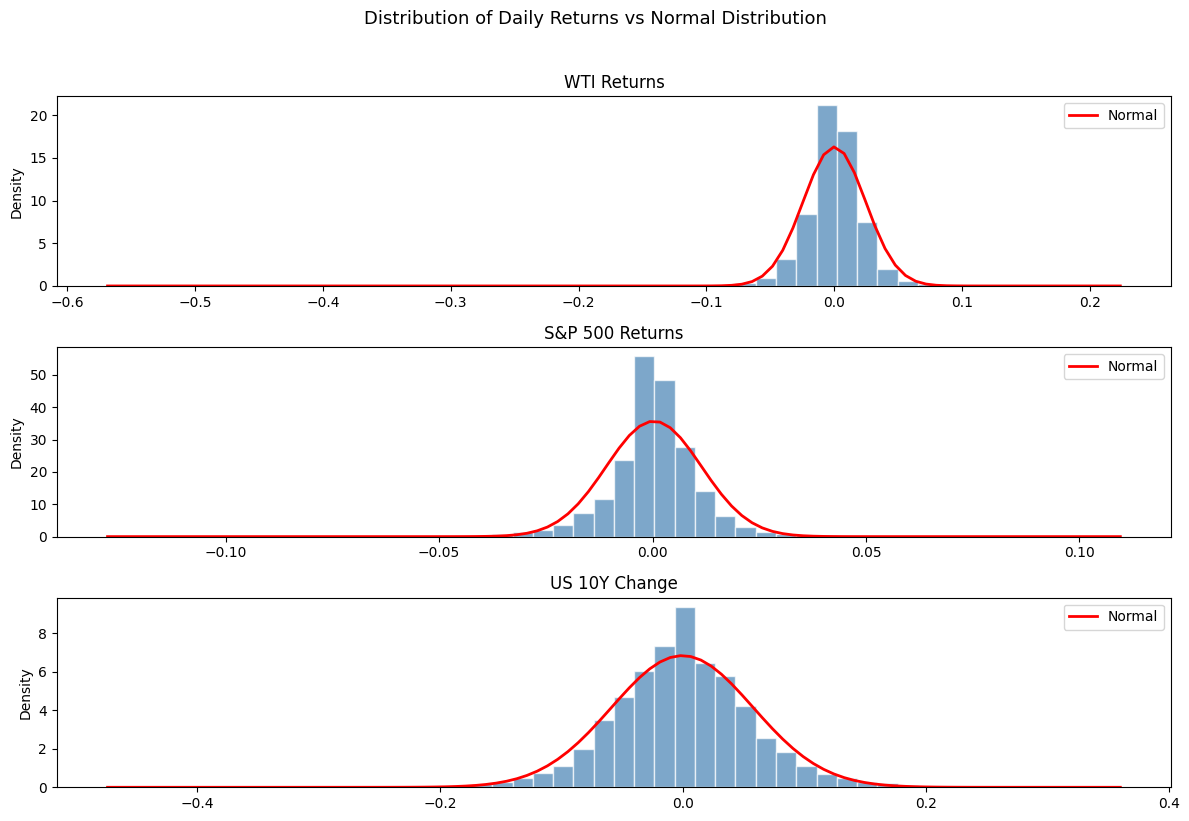

In [108]:
# Plot the distributions of our main return series
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

for ax, col, lab in zip(axes.flat, returns_cols, labels):
    s = data[col]
    ax.hist(s, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
    
    # overlay normal distribution for comparison
    x = np.linspace(s.min(), s.max(), 100)
    ax.plot(x, stats.norm.pdf(x, s.mean(), s.std()), 'r-', lw=2, label='Normal')
    
    ax.set_title(lab)
    ax.legend()
    ax.set_ylabel('Density')

plt.suptitle('Distribution of Daily Returns vs Normal Distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Time Series Vizualisation

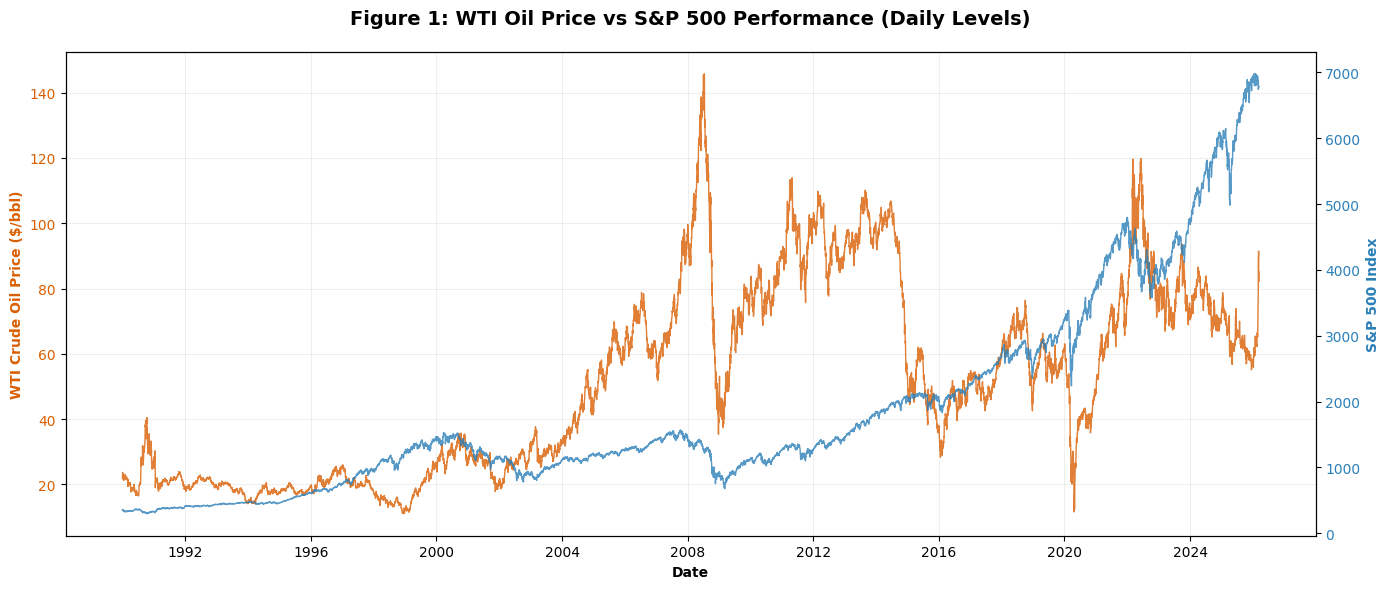

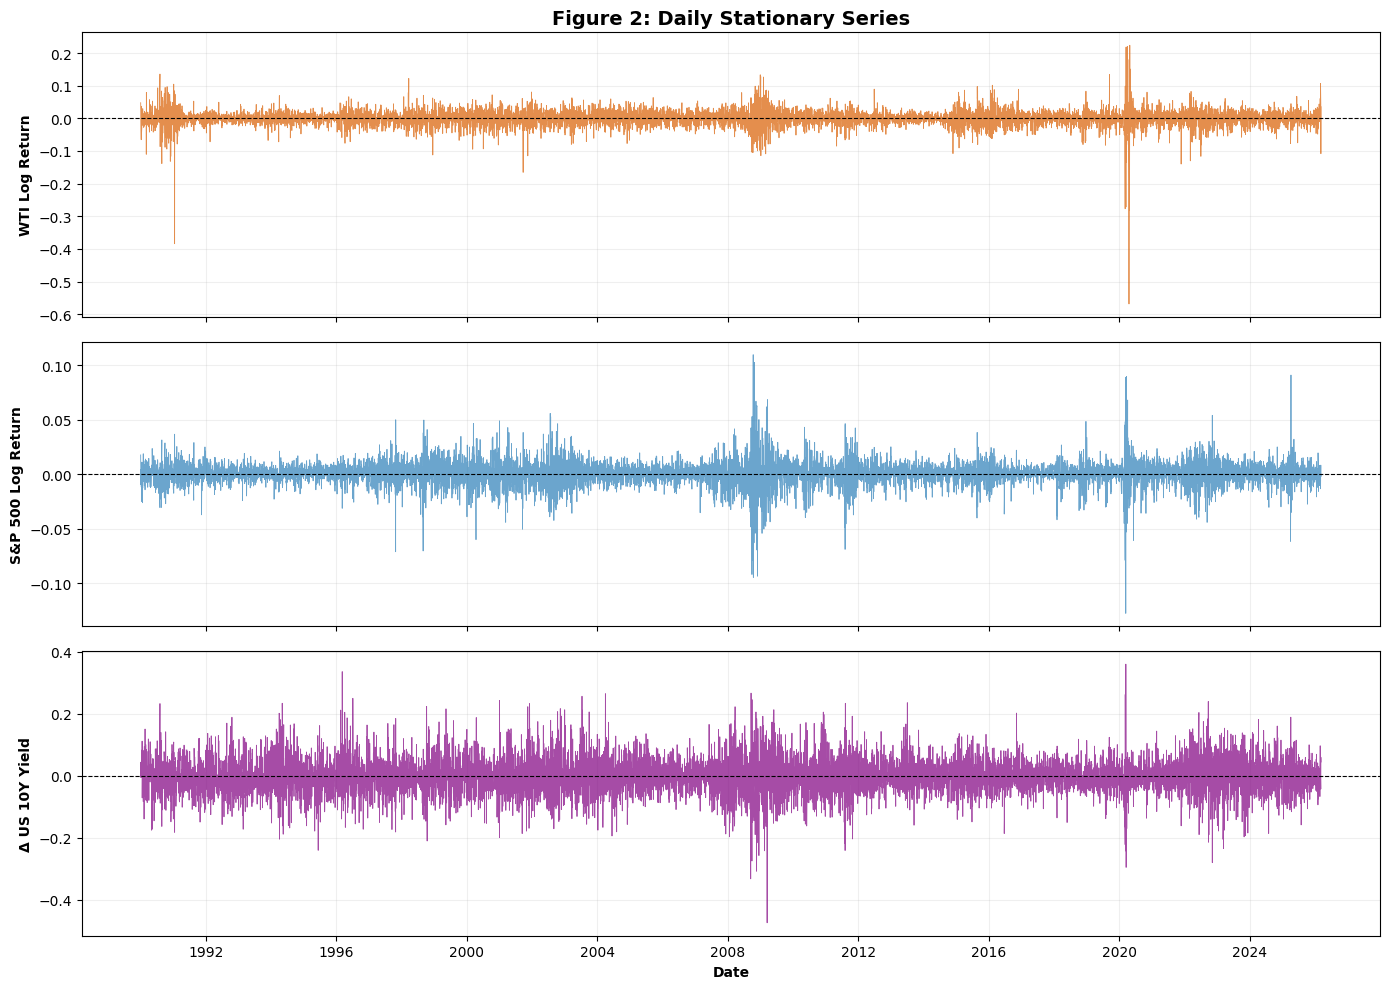

In [109]:
# If Date is a column
x_daily = daily['Date'] if 'Date' in daily.columns else daily.index
x_data = data['Date'] if 'Date' in data.columns else data.index

# =========================
# FIGURE 1: LEVELS
# =========================

fig, ax1 = plt.subplots(figsize=(14, 6))

# WTI (orange)
color_wti = '#d95f02'
ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('WTI Crude Oil Price ($/bbl)', color=color_wti, fontweight='bold')
ax1.plot(x_daily, daily['WTI futures'], color=color_wti, linewidth=1, alpha=0.8, label='WTI Oil')
ax1.tick_params(axis='y', labelcolor=color_wti)
ax1.grid(True, alpha=0.2)

# S&P 500 (blue)
color_sp = '#2c7fb8'
ax2 = ax1.twinx()
ax2.set_ylabel('S&P 500 Index', color=color_sp, fontweight='bold')
ax2.plot(x_daily, daily['S&P500'], color=color_sp, linewidth=1, alpha=0.8, label='S&P 500')
ax2.tick_params(axis='y', labelcolor=color_sp)

plt.title('Figure 1: WTI Oil Price vs S&P 500 Performance (Daily Levels)',
          fontsize=14, fontweight='bold', pad=20)

fig.tight_layout()
plt.show()


# =========================
# FIGURE 2: STATIONARY SERIES
# =========================

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 1. WTI returns (orange)
axes[0].plot(x_data, data['r_WTI'], color=color_wti, alpha=0.7, linewidth=0.6)
axes[0].set_ylabel('WTI Log Return', fontweight='bold')
axes[0].set_title('Figure 2: Daily Stationary Series', fontsize=14, fontweight='bold')
axes[0].axhline(0, color='black', lw=0.8, linestyle='--')
axes[0].grid(True, alpha=0.2)

# 2. S&P 500 returns (blue)
axes[1].plot(x_data, data['r_SP500'], color=color_sp, alpha=0.7, linewidth=0.6)
axes[1].set_ylabel('S&P 500 Log Return', fontweight='bold')
axes[1].axhline(0, color='black', lw=0.8, linestyle='--')
axes[1].grid(True, alpha=0.2)

# 3. US 10Y changes (purple)
color_rate = 'purple'
axes[2].plot(x_data, data['d_US10Y'], color=color_rate, alpha=0.7, linewidth=0.6)
axes[2].set_ylabel('Δ US 10Y Yield', fontweight='bold')
axes[2].set_xlabel('Date', fontweight='bold')
axes[2].axhline(0, color='black', lw=0.8, linestyle='--')
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 6. Correlation
Before building our VAR model, we examine the cross-correlations between variables. From the course (Section 2B), we know that correlation measures linear dependence, and that we should be careful because uncorrelated does not mean independent.

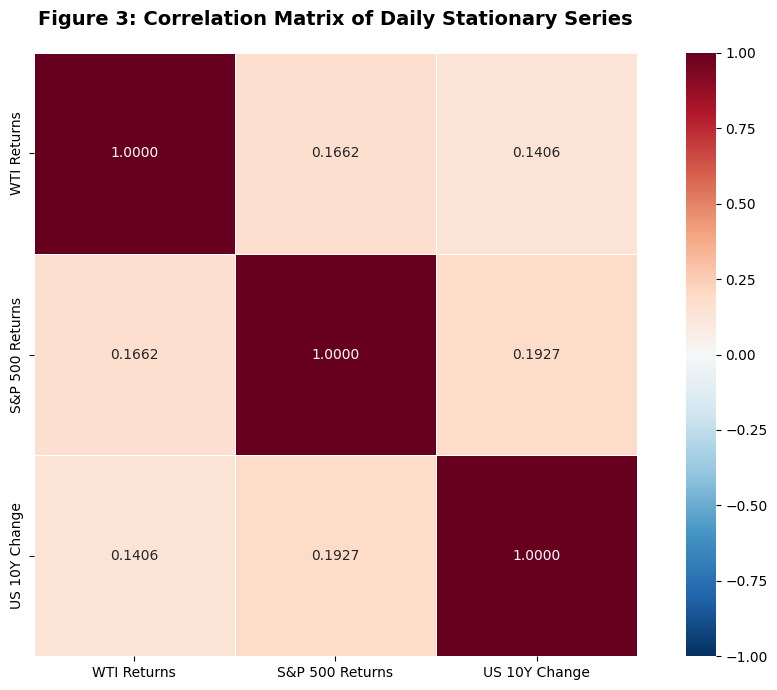

------------------------------
CORRELATION KEY OBSERVATIONS:
------------------------------
WTI vs S&P 500:  0.1662
WTI vs US 10Y:    0.1406
S&P 500 vs US 10Y: 0.1927
------------------------------


In [110]:
# --- CORRELATION ANALYSIS (DAILY) ---
# We examine the contemporaneous linear relationships between our endogenous variables.
# This helps justify the lead-lag dynamics explored later in the VAR model.

import seaborn as sns

# Define the daily variables and clean labels
corr_vars = ['r_WTI', 'r_SP500', 'd_US10Y']
corr_labels = ['WTI Returns', 'S&P 500 Returns', 'US 10Y Change']

# Compute correlation matrix
corr_matrix = data[corr_vars].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True, linewidths=.5)

plt.title('Figure 3: Correlation Matrix of Daily Stationary Series', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Key Observations for your report
print("-" * 30)
print("CORRELATION KEY OBSERVATIONS:")
print("-" * 30)
print(f"WTI vs S&P 500:  {corr_matrix.iloc[0,1]:.4f}")
print(f"WTI vs US 10Y:    {corr_matrix.iloc[0,2]:.4f}")
print(f"S&P 500 vs US 10Y: {corr_matrix.iloc[1,2]:.4f}")
print("-" * 30)

## 7. Model implementation
### 7.1 Choice of lag

In [111]:
model = VAR(daily_transformed[["wti_return", "sp500_return", "d_us10y"]])

#Searching for optimal lag order between 1 and 12
lag_results = model.select_order(maxlags=12)

print("Information Criteria for Lag Selection:")
print(lag_results.summary())

#Choosing BIC: simpler, more partimonious by imposing a higher penalty for unecessary lags
optimal_lag = lag_results.bic
print(f"Optimal Lag Order (BIC): {optimal_lag}")

Information Criteria for Lag Selection:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -22.17      -22.17   2.348e-10      -22.17
1       -22.18     -22.17*   2.324e-10     -22.18*
2       -22.18      -22.17   2.319e-10      -22.18
3       -22.19      -22.16   2.314e-10      -22.18
4       -22.19      -22.16   2.309e-10      -22.18
5       -22.19      -22.15   2.310e-10      -22.18
6      -22.19*      -22.15  2.305e-10*      -22.18
7       -22.19      -22.14   2.306e-10      -22.17
8       -22.19      -22.13   2.308e-10      -22.17
9       -22.19      -22.13   2.309e-10      -22.17
10      -22.19      -22.12   2.310e-10      -22.16
11      -22.19      -22.11   2.312e-10      -22.16
12      -22.19      -22.10   2.314e-10      -22.16
--------------------------------------------------
Optimal Lag Order (BIC): 1


### 5.2 Defining oil price shocks

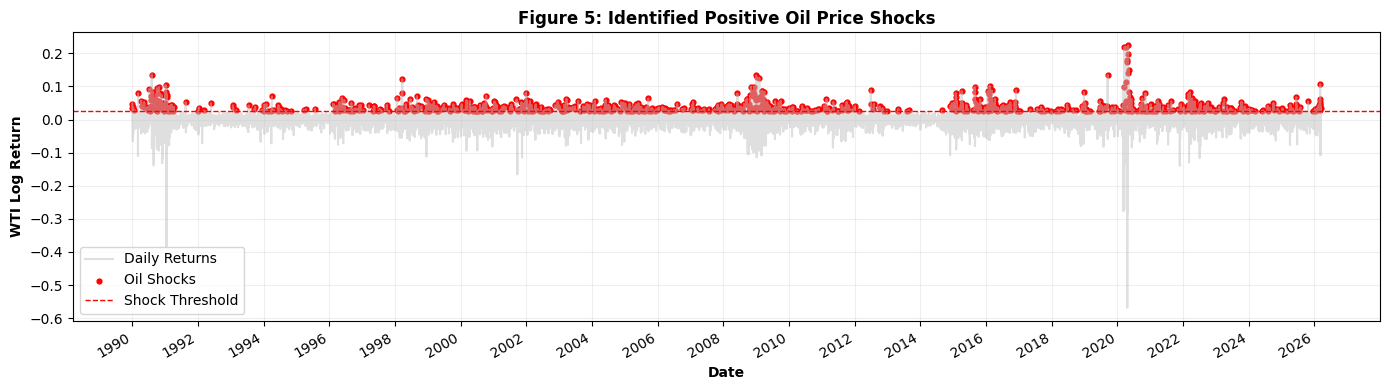

In [112]:
# Repartir de daily en gardant Date
data = daily[['Date', 'WTI futures', 'S&P500', 'US 10-year Rate']].copy()

# Transformations
data['r_WTI'] = np.log(data['WTI futures'] / data['WTI futures'].shift(1))
data['r_SP500'] = np.log(data['S&P500'] / data['S&P500'].shift(1))
data['d_US10Y'] = data['US 10-year Rate'].diff()

# Supprimer les NA tout en gardant Date
data = data.dropna().reset_index(drop=True)

# Définition des shocks
threshold = data['r_WTI'].mean() + data['r_WTI'].std()
data['is_shock'] = (data['r_WTI'] > threshold).astype(int)

# Plot
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(data['Date'], data['r_WTI'], color='silver', alpha=0.5, label='Daily Returns')

ax.scatter(
    data.loc[data['is_shock'] == 1, 'Date'],
    data.loc[data['is_shock'] == 1, 'r_WTI'],
    color='red',
    s=12,
    label='Oil Shocks'
)

ax.axhline(threshold, color='red', linestyle='--', linewidth=1, label='Shock Threshold')

ax.set_title('Figure 5: Identified Positive Oil Price Shocks', fontweight='bold')
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('WTI Log Return', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.2)

# Format de date lisible
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

### 5.3 VAR implementation 
#### 5.3.1 Summary of Regression Results

In [113]:
#Implementing the VAR model with the optimal lag order
results = model.fit(optimal_lag)

#Creating a table to see if the price of oil yesterday has a significant effect on the S&P 500 today, controlling for the interest rate
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 31, Mar, 2026
Time:                     19:23:11
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -22.1734
Nobs:                     9441.00    HQIC:                  -22.1794
Log likelihood:           64535.7    FPE:                2.32424e-10
AIC:                     -22.1825    Det(Omega_mle):     2.32129e-10
--------------------------------------------------------------------
Results for equation wti_return
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   0.000131         0.000252            0.518           0.604
L1.wti_return          -0.004864         0.010503           -0.463           0.643
L1.sp500_return         0.030602         0.0232

#### 5.3.2 Test statistic of significance for S&P 500 returns

In [114]:
target_variable = "sp500_return"

df_results = pd.DataFrame({
    'Coefficient': results.params[target_variable],
    'p-value': results.pvalues[target_variable]
})

# Add significance stars based on p-value thresholds
def add_stars(p):
    if p < 0.01:
        return '***'
    elif p < 0.05:
        return '**'
    elif p < 0.1:
        return '*'
    else:
        return ''
    
df_results['[Significance'] = df_results['p-value'].apply(add_stars)

# Format coefficients and append significance stars
df_results['Coefficient'] = df_results['Coefficient'].map('{:.4f}'.format) + df_results['[Significance']
df_results = df_results[['Coefficient', 'p-value']]

print(f"Table of significance for {target_variable}")
print("-" * 45)
print(df_results)
print("-" * 45)
print("Note: *** p<0.01, ** p<0.05, * p<0.1")

Table of significance for sp500_return
---------------------------------------------
                Coefficient       p-value
const             0.0003***  3.737217e-03
L1.wti_return       -0.0078  1.042877e-01
L1.sp500_return  -0.0714***  1.344823e-11
L1.d_us10y       -0.0056***  5.122567e-03
---------------------------------------------
Note: *** p<0.01, ** p<0.05, * p<0.1
